In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Cleaning Data
#### วิธีทำ
1. Load data
2. Data Reshaping (Pivot Table)
3.  Return Transformation (Daily Log Returns)
4.  Handling Missing Values (ตัดหุ้นที่มีค่าว่างออก)
5.  Standardization & Transpose (ปรับสเกลและสลับมิติให้หุ้นเป็น Samples พร้อมเข้าโมเดล)

In [64]:
# step 1
df = pd.read_csv('NASDAQ-100/NASDAQ_100_Data_From_2010.csv', sep='\t')
df['Date'] = pd.to_datetime(df['Date'])

# step 2
price_matrix = df.pivot(index='Date', columns='Name', values='Adj Close')

#step 3 
returns_matrix = np.log(price_matrix / price_matrix.shift(1)).iloc[1:]

# step 4 
clean_returns = returns_matrix.dropna(axis=1)

# step 5 
scaler = StandardScaler()
# X = scaler.fit_transform(clean_returns).T
X = scaler.fit_transform(clean_returns)


stock_names = clean_returns.columns.tolist()
print(stock_names)

['AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP', 'ALGN', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANSS', 'ASML', 'ATVI', 'AVGO', 'BIDU', 'BIIB', 'BKNG', 'CDNS', 'CERN', 'CHKP', 'CMCSA', 'COST', 'CPRT', 'CSCO', 'CSX', 'CTAS', 'CTSH', 'DLTR', 'DXCM', 'EA', 'EBAY', 'EXC', 'FAST', 'FISV', 'GILD', 'GOOG', 'GOOGL', 'HON', 'IDXX', 'ILMN', 'INCY', 'INTC', 'INTU', 'ISRG', 'KDP', 'KLAC', 'LRCX', 'LULU', 'MAR', 'MCHP', 'MDLZ', 'MELI', 'MNST', 'MRVL', 'MSFT', 'MTCH', 'MU', 'NFLX', 'NTES', 'NVDA', 'ORLY', 'PAYX', 'PCAR', 'PEP', 'QCOM', 'REGN', 'ROST', 'SBUX', 'SGEN', 'SIRI', 'SNPS', 'SWKS', 'TCOM', 'TMUS', 'TXN', 'VRSK', 'VRSN', 'VRTX', 'WBA', 'XEL', 'XLNX']


## PCA

In [65]:
from sklearn.decomposition import PCA

#### กำหนดจำนวน Component ที่ต้องการ

In [74]:
pca = PCA(n_components=43, random_state=0)
pca_features = pca.fit_transform(X)
print(pca_features)

[[ 1.43115939  0.04307051  0.90520147 ...  0.24954557 -0.39840706
   1.38626842]
 [-0.09157169  1.55999921  0.86670327 ... -0.62745225 -0.42868129
   0.85802635]
 [-1.83020747  1.93055607 -0.90878    ... -0.34515232  0.24085887
   1.14616104]
 ...
 [ 0.53404667  4.7550782   0.22211776 ...  0.20038781 -0.3138157
  -0.525837  ]
 [-2.18803531 -1.51104185 -3.62945713 ... -0.21900316 -0.87479801
   0.00645497]
 [-1.91142529 -2.65894685 -0.6372916  ...  0.96534922  0.25107724
  -0.33736015]]


#### ดูสัดส่วน Variance ที่แต่ละ Principal Component อธิบายได้

In [67]:
exp = pca.explained_variance_ratio_
cum_var = np.cumsum(exp)
print("Explained Variance Ratio per PC: \n", exp)
print("Cumulative Variance Explained: \n", cum_var)

Explained Variance Ratio per PC: 
 [0.39142476 0.04242958 0.02978712 0.02207212 0.02143699 0.01535845
 0.01469415 0.01367215 0.01273301 0.01111712 0.01077297 0.01067759
 0.01039983 0.01001344 0.00983731 0.00957817 0.00948034 0.00922057
 0.00898258 0.00889297 0.00856259 0.00843568 0.00835401 0.00831696
 0.00820428 0.00802683 0.00796086 0.00782905 0.00765815 0.00746154
 0.00737841 0.00720638 0.00707426 0.00701256 0.00681946 0.00675088
 0.00660104 0.00649111 0.00642714 0.0063796  0.00634583 0.00624577
 0.00616329]
Cumulative Variance Explained: 
 [0.39142476 0.43385434 0.46364145 0.48571358 0.50715057 0.52250902
 0.53720317 0.55087533 0.56360834 0.57472546 0.58549843 0.59617601
 0.60657584 0.61658928 0.62642658 0.63600475 0.64548509 0.65470566
 0.66368825 0.67258122 0.68114381 0.68957949 0.69793349 0.70625046
 0.71445474 0.72248157 0.73044243 0.73827147 0.74592962 0.75339117
 0.76076958 0.76797596 0.77505022 0.78206277 0.78888223 0.79563311
 0.80223415 0.80872526 0.81515241 0.821532   0.8

## กราฟดูสัดส่วน Variance แต่ละ Principal Component
#### วิธีการทำ
1. ดึงค่า Variance
2. ทำกราฟแท่ง: สัดส่วน Variance ของแต่ละ PC
3. ทำกราฟเส้น: สัดส่วน Variance สะสม (Cumulative)
4. เพิ่มตัวเลขกำกับบนจุดของ Cumulative Line เพื่อให้อ่านค่าง่ายขึ้น
5. เพิ่มเส้นประสีแดงสมมติที่ระดับ 75% (Target Threshold)

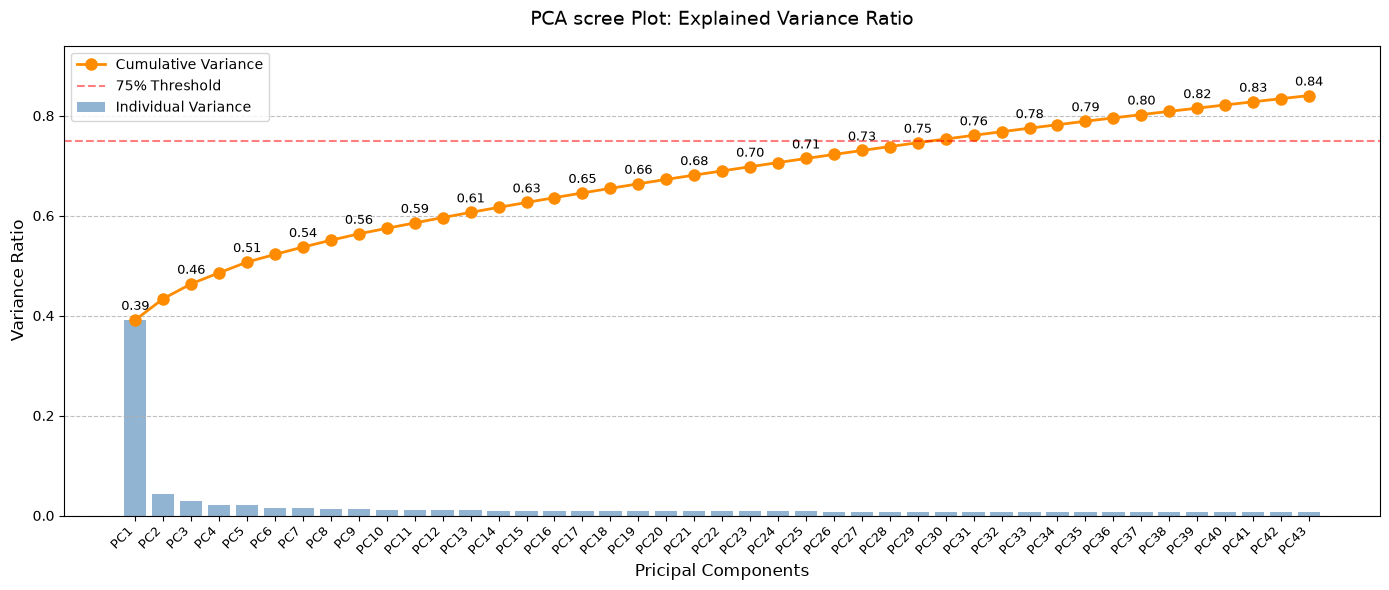

In [68]:
# step 1
exp = pca.explained_variance_ratio_
cum_var = np.cumsum(exp)
x_labels = [f"PC{i + 1}" for i in range(len(exp))]
x_pos = np.arange(len(exp))

# step 2 
plt.figure(figsize=(14, 6))
plt.bar(x_pos, exp, alpha=0.6, color='steelblue', label='Individual Variance')

# step 3 
plt.plot(x_pos, cum_var, marker='o', color='darkorange', linewidth=2, markersize=8, label='Cumulative Variance')

# step 4 
for i, v in enumerate(cum_var):
    if i % 2 == 0:
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center', color='black', fontsize=9)

# step 5 
plt.axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='75% Threshold')

plt.title('PCA scree Plot: Explained Variance Ratio', fontsize=14, pad=15)
plt.xlabel('Pricipal Components', fontsize=12)
plt.ylabel('Variance Ratio', fontsize=12)
plt.ylim(0, max(cum_var) + 0.1)
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.8)

# เพิ่มช่องว่าระหว่างกราฟ
step = 1
plt.xticks(x_pos[::step], x_labels[::step], rotation=45, ha='right', fontsize=9)
plt.tight_layout()

plt.show()

# การนำผล PCA ไปใช้ใน Portfolio Optimization
1. Reconstructed Correlation Matrix
   - สร้าง Matrix ความสัมพันธ์ใหม่โดยใช้เฉพาะ Top PCs ตัด Noise ความสัมพันธ์แบบสุ่มออก
2. Eigen Portfolios
   - ใช้ Component Weights (Eigenvectors) ของแต่ละ PC มาเป็นน้ำหนักการลงทุน
3. Risk Factor Decomposition
   - แยกความเสี่ยงของพอร์ตออกเป็น Systemic Risk (ที่มาจาก Top PCs) และ Specific Risk ของหุ้นแต่ละตัว ช่วยตั้งจำกัดกรอบความเสี่ยง (Risk Budgeting)


# Reconstructed Correlation Matrix
1. ทำ PCA และเลือกจำนวน Component ($k$)
   - ทำ PCA กับข้อมูลที่ Scaled แล้ว
   - ดู Cumulative Variance เพื่อเลือกจำนวน k (เช่น เลือกระดับที่อธิบายความผันผวนได้ ~70-80%)
2. สร้าง Reconstructed Correlation Matrix
   - ดึง Top k Components และ Eigenvalues
   - คำนวณ Reconstructed Matrix
   - ปรับระดับเส้นทแยงมุม (Diagonal) ให้เป็น 1.0 เสมอตามสมบัติของ Correlation Matrix
   - แปลงเป็น DataFrame พร้อมใส่ Ticker

In [78]:
# step 1 
# step 1.1
pca2 = PCA()
score = pca2.fit_transform(X)

# step 1.2 
cum_var = np.cumsum(pca2.explained_variance_ratio_)
k = np.argmax(cum_var >= 0.75) + 1  # เลือกจำนวน k ที่คลอบคลุม Variance 75%
print(f"Selected Top K components: {k}")

# step 2 
# step 2.1 
V = pca2.components_[:k, :]
exp_var = pca2.explained_variance_[:k]

# step 2.2 
R_raw = V.T @ np.diag(exp_var) @ V

# step 2.3
diag_vals = np.diag(R_raw)
d = np.sqrt(np.maximum(diag_vals, 1e-10))
R_reconstructed = R_raw / np.outer(d, d)

# step 2.4 
denoised_corr_df = pd.DataFrame(
    R_reconstructed,
    index=clean_returns.columns,
    columns=clean_returns.columns
)

denoised_corr_df.head()

Selected Top K components: 30


Name,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALGN,AMAT,AMD,AMGN,...,SWKS,TCOM,TMUS,TXN,VRSK,VRSN,VRTX,WBA,XEL,XLNX
Name,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.656618,0.658317,0.616985,0.594633,0.330122,0.464935,0.643485,0.437146,0.527491,...,0.781470,0.425992,0.344475,0.692140,0.548245,0.639630,0.333932,0.407406,0.359846,0.578811
ADBE,0.656618,1.000000,0.708973,0.756920,0.924534,0.349414,0.596133,0.690607,0.506988,0.598348,...,0.608190,0.433594,0.454246,0.741125,0.620344,0.747228,0.405181,0.398191,0.392612,0.724265
ADI,0.658317,0.708973,1.000000,0.747296,0.754875,0.314724,0.591039,0.933468,0.585463,0.586652,...,0.897978,0.464579,0.398571,0.984034,0.590017,0.647612,0.340514,0.405862,0.356272,0.956555
ADP,0.616985,0.756920,0.747296,1.000000,0.735962,0.567818,0.574030,0.688211,0.426965,0.727885,...,0.615041,0.404695,0.391166,0.762288,0.809998,0.761001,0.419155,0.501636,0.628147,0.663446
ADSK,0.594633,0.924534,0.754875,0.735962,1.000000,0.313289,0.654045,0.731430,0.540874,0.521360,...,0.661462,0.503264,0.432474,0.769592,0.538949,0.695228,0.413114,0.448360,0.334952,0.776302


## หุ้นที่มีอิทธิพลสูงสุด ในแต่ละ Component
#### วิธีการทำ
1. ดึง Weight (Loadings) ของหุ้นแต่ละตัวในแต่ละ PC
2. ดู Top 5 หุ้นที่มีอิทธิพลสูงสุดต่อภาพรวมตลาด (PC1)
3. ดู Top 5 หุ้นที่เป็นตัวแทนของ Factor ที่ 2 (PC2)

In [83]:
# step 1 
loadings = pd.DataFrame(
    pca2.components_.T,
    index=clean_returns.columns,
    columns=[f'PC{i + 1}' for i in range(pca2.components_.shape[0])]
)

# step 2 
print("--- Top 5 Market-Driven Stocks (PC1) ---")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

# step 3
print("\n--- Top 5 Sector-Driven Stocks (PC2) ---")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

--- Top 5 Market-Driven Stocks (PC1) ---
Name
TXN     0.142441
ADI     0.139488
ADP     0.137445
SNPS    0.136622
MCHP    0.136456
Name: PC1, dtype: float64

--- Top 5 Sector-Driven Stocks (PC2) ---
Name
XEL     0.329417
AEP     0.320383
EXC     0.269247
PEP     0.255190
MDLZ    0.201320
Name: PC2, dtype: float64


## Graph Scree Plot

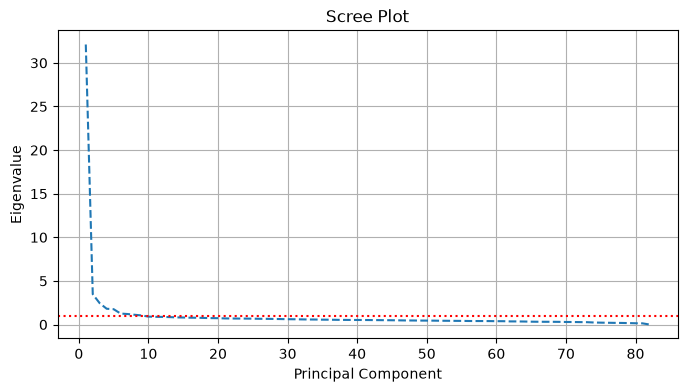

In [84]:
eig = pca2.explained_variance_
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(eig) + 1), eig, linestyle="--"
)
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.axhline(y=1, color="r", linestyle=":")
plt.grid(True)
plt.show()